## 1. 임베딩 층은 룩업 테이블이다.
- 임베딩 층은 입력 정수에 대해 밀집 벡터(dense vector)로 매핑
- 이 밀집 벡터는 인공 신경망의 학습 과정에서 가중치가 학습되는 것과 같은 방식으로 훈련

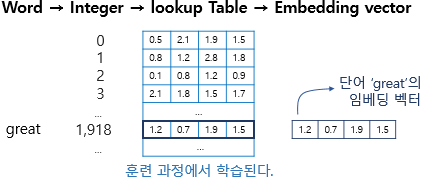

- 파이토치는 원-핫 인코딩이 되지 않은, 정수 인덱스 상태의 단어를 입력해도 임베딩 벡터를 리턴함

In [1]:
import torch
import torch.nn as nn

In [2]:
train_data = 'you need to know how to code'

# 중복을 제거한 단어들의 집합인 단어 집합 생성.
word_set = set(train_data.split())

# 단어 집합의 각 단어에 고유한 정수 맵핑.
vocab = {word: i+2 for i, word in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1
print(vocab)

{'know': 2, 'to': 3, 'need': 4, 'you': 5, 'how': 6, 'code': 7, '<unk>': 0, '<pad>': 1}


In [ ]:
# 단어 집합의 크기만큼의 행을 가지는 테이블 생성.
embedding_table = torch.FloatTensor([
                               [ 0.0,  0.0,  0.0],
                               [ 0.0,  0.0,  0.0],
                               [ 0.2,  0.9,  0.3],
                               [ 0.1,  0.5,  0.7],
                               [ 0.2,  0.1,  0.8],
                               [ 0.4,  0.1,  0.1],
                               [ 0.1,  0.8,  0.9],
                               [ 0.6,  0.1,  0.1]
                               ])

In [4]:
sample = 'you need to run'.split()
idxes = []

# 각 단어를 정수로 변환
for word in sample:
  try:
    idxes.append(vocab[word])
  # 단어 집합에 없는 단어일 경우 <unk>로 대체된다.
  except KeyError:
    idxes.append(vocab['<unk>'])
idxes = torch.LongTensor(idxes)

# 각 정수를 인덱스로 임베딩 테이블에서 값을 가져온다.
lookup_result = embedding_table[idxes, :]
print(lookup_result)

tensor([[0.4000, 0.1000, 0.1000],
        [0.2000, 0.1000, 0.8000],
        [0.1000, 0.5000, 0.7000],
        [0.0000, 0.0000, 0.0000]])


## 2. 임베딩 층 사용하기

In [5]:
train_data = 'you need to know how to code'

# 중복을 제거한 단어들의 집합인 단어 집합 생성.
word_set = set(train_data.split())

# 단어 집합의 각 단어에 고유한 정수 맵핑.
vocab = {tkn: i+2 for i, tkn in enumerate(word_set)}
vocab['<unk>'] = 0
vocab['<pad>'] = 1

In [6]:
embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                               embedding_dim=3,
                               padding_idx=1)

In [7]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.5476,  0.4415, -1.5449],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0777,  0.5106,  1.1816],
        [-2.2171,  1.9258,  0.3712],
        [-0.0141,  0.0329, -0.6140],
        [ 0.9095, -0.6183,  0.1737],
        [ 0.0298,  0.4398, -1.3415],
        [-1.1527,  0.2894, -2.7600]], requires_grad=True)
